In [1]:
import matplotlib.pyplot as plt
import polars as pl

import parcels

/tmp/ipykernel_2992425/3671891571.py:4: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


In [2]:
df = parcels.read_particlefile("Simulations/Simulation_Satellite_kN_0.001.parquet")

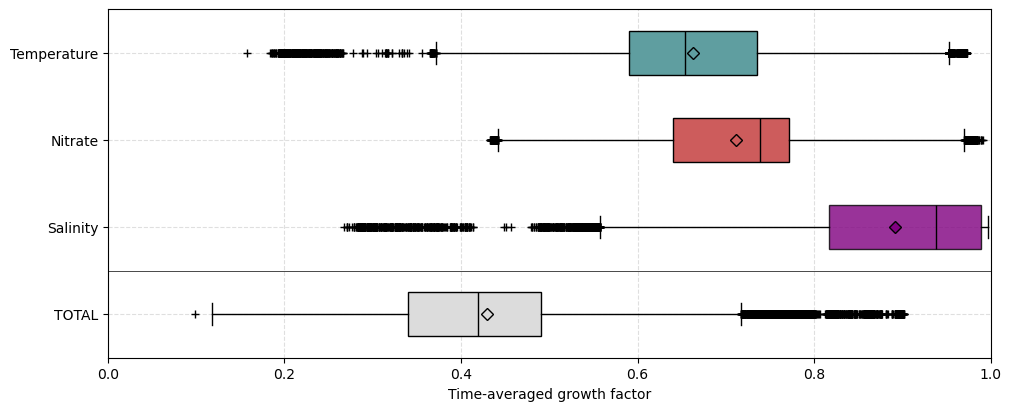

In [3]:
plt.figure(figsize=(10, 4), constrained_layout=True)

vars = ['limitation', 'lim_salinity', 'lim_no3', 'lim_temp']
limitation_names = ['TOTAL', 'Salinity', 'Nitrate', 'Temperature']
colors = ['gainsboro', 'purple' , 'indianred', 'cadetblue']
alphas = [1, 0.8, 1, 1]

#Boxplots with different colors
for i, var in enumerate(vars):
    _, data = df.group_by('particle_id').agg(pl.col(var).mean())
    plt.boxplot(
        data,
        positions=[i],
        widths=0.5,
        patch_artist=True,
        orientation='horizontal',
        boxprops=dict(facecolor=colors[i], alpha=alphas[i]),
        medianprops=dict(color='black'),
        showmeans=True,
        meanprops = dict(marker='D',markeredgecolor='black', markerfacecolor=colors[i]),
        sym='+',
    )

plt.yticks(range(4) , limitation_names, rotation=0)
plt.xlabel('Time-averaged growth factor')
plt.xlim(0, 1)
plt.hlines(0.5, 0, 1, colors='black', linewidth=0.5)
plt.grid( linestyle='--', alpha=0.4)
plt.savefig('Figures/Figure4.pdf', bbox_inches='tight', dpi=300)
plt.show()